In [1]:
import pandas as pd
df = pd.read_csv('creditcard.csv')
print(df.shape)
print(df['Class'].value_counts())

(284807, 31)
Class
0    284315
1       492
Name: count, dtype: int64


In [2]:
print(df.isnull().sum().sum())  # should be 0

from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
df['Amount_scaled'] = scaler.fit_transform(df[['Amount']])
df['Time_scaled'] = scaler.fit_transform(df[['Time']])
df = df.drop(['Amount', 'Time'], axis=1)

0


In [3]:
from sklearn.model_selection import train_test_split

X = df.drop('Class', axis=1)
y = df['Class']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

In [4]:
from sklearn.ensemble import IsolationForest

iso = IsolationForest(contamination=0.0017, random_state=42)
iso.fit(X_train)
iso_pred = iso.predict(X_test)
iso_pred = [1 if x == -1 else 0 for x in iso_pred]  # convert to 0/1 labels

In [5]:
from sklearn.neighbors import LocalOutlierFactor

lof = LocalOutlierFactor(n_neighbors=20, contamination=0.0017, novelty=False)
lof_pred = lof.fit_predict(X_test)
lof_pred = [1 if x == -1 else 0 for x in lof_pred]

In [6]:
from xgboost import XGBClassifier

xgb = XGBClassifier(random_state=42, eval_metric='logloss')
xgb.fit(X_train, y_train)
xgb_pred = xgb.predict(X_test)

In [7]:
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score

print(classification_report(y_test, xgb_pred))
print(confusion_matrix(y_test, xgb_pred))
print("ROC-AUC:", roc_auc_score(y_test, xgb.predict_proba(X_test)[:, 1]))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56864
           1       0.90      0.80      0.84        98

    accuracy                           1.00     56962
   macro avg       0.95      0.90      0.92     56962
weighted avg       1.00      1.00      1.00     56962

[[56855     9]
 [   20    78]]
ROC-AUC: 0.9219230021074272


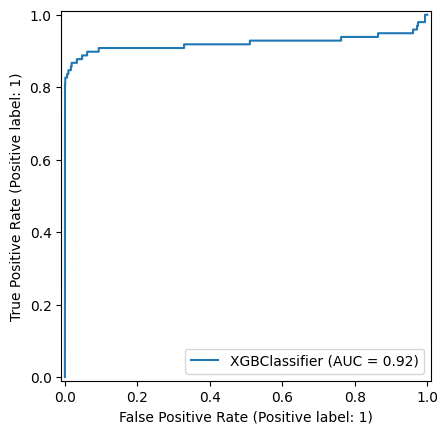

In [8]:
from sklearn.metrics import RocCurveDisplay
RocCurveDisplay.from_estimator(xgb, X_test, y_test)
import matplotlib.pyplot as plt
plt.show()

In [10]:
   import joblib
   joblib.dump(xgb, 'fraud_model.pkl')

['fraud_model.pkl']